# Localizing with TEM-t Over Fourier Codes

In [Localizing with TEM](localizing_with_tem.ipynb) we used a TEM model to localize a point using belief maps and convolutions. But the TEM paper, and the brain generally, uses Fourier location codes. 

## Fourier Location Encoding

Grid cells in $d$ dimensions (usually $d=2$) fire with a rate described by
$$
r_j(x) = \left(\sum_{i=1}^{d+1} A_{ij} \cos\left(\vphantom{x^x}k_{i}\cdot x + \phi_{ij}\right)\right)_+
$$
when the organism is at position $x$, where $A_{ij}$ is a fixed amplitude and $k_{i}$ is a wave vector, one of $d + 1$ unit vectors whose convex hull forms the simplex. In 2-D, these vectors start at the origin and are radially separated by $120^\circ$. In 3-D, four wavevectors are needed, pointing the the vertices of a triangular pyramid.

We can model these cells via an assemblage of column vectors having the form
$$
\eta_{ij}(x) = \left(\begin{array}{c}
    \cos (\alpha_j k_i\cdot x + \phi_j) \\
    \sin (\alpha_j k_i\cdot x + \phi_j)
\end{array}\right)
$$
where the $\{\phi_j\}$ are chosen to cover the interval $[0, 2\pi)$. Sufficiently wide choices of $\phi_j$ will cover the full circle.

Grid cell responses are periodic as the animal moves around its environment, and thanks to the identity
$$
\cos a \cos b  + \sin a \sin b = \cos (a - b) = \cos (b - a)
$$
we can arrive a relationship between displacement in physical space and rotation in Fourier space. To do this, we form a matrix $K$ whose rows range over $k_i$, so that $K$ is a $(d+1) \times d$ matrix. The rows of $K$ span $\mathbb{R}^d$, so the $d \times d$ matrix $K^TK$ is invertible, and the $d \times (d+1)$ pseudoinverse of this matrix is $K^\dagger = (K^TK)^{-1}K^T$ has $K^\dagger K = I$. Then we have
$$
\left(\vphantom{x^{x^x}}\eta_{ij}(x), \,\eta_{ij}(x + \Delta x)\right) \,\,=\,\, 
\cos(\alpha_j k_i\cdot \Delta x)
\quad\quad\text{whence}\quad\quad \forall n_j \in \mathbb{Z}^{d+1},\quad
\alpha_j K \Delta x = 2\pi n_j + \mathrm{arccos} \left(\vphantom{x^{x^{x^x}}}\Eta_{j}(x)^T\,\Eta_{j}(x + \Delta x)\right)
$$
where $\Eta_j(x)$ is the $(d+1) \times 2$ matrix whose columns are $\eta_{ij}(x)$.
Solving for $\Delta x$, we find
$$
\forall j\,\,
\exists n_j \in \mathbb{Z}^{d+1}\quad\text{s.t.}\quad\quad
\Delta x = \frac{2\pi K^\dagger\,n_j}{\alpha_j} + \frac{K^\dagger}{\alpha_j} \Delta \theta_{j}\quad\quad\text{given}\quad\quad\Delta\theta_{j} = \mathrm{arccos} \left(\vphantom{x^{x^{x^x}}}\Eta_{j}(x)^T\,\Eta_{j}(x + \Delta x)\right)
$$
With sufficient and carefully chosen $(\alpha_j, \phi_j)$, these modular constraints can be solved for a wide range of $\Delta x$, and $\Delta x$ can be identified exactly on this range.

So the firing rates of an assemblage of grid cells with different phases $\phi_j$ can be stably and reliably inverted to retrieve the physical location $x$.

Without digressing further, we can use location codes of the form $\ell \in [-1, 1]^D$ to encode physical location, using dot products $(\ell, \ell')$ to express location affinity in a spatial memory as we have been doing with [real vectors](./map_testing.ipynb) or [location beliefs](./belief-maps.ipynb). The Fourier encoding, however, has the benefit of acting just like a normal transformer, since we can compute a location affinity by just taking dot products.

## Simultaneous Localization and Mapping (SLAM), Neural Style

It's all very nice that grid cells can move freely between a Fourier-like code and physical displacement, $\Delta x \leftrightarrow \Delta \theta$, but our problem is that we don't know _either_ the displacement or the location. All we have is sequences of sensory percepts $z = (z_1, \ldots, z_T)$ and actions $a = (a_1, \ldots, a_T)$. From this, we want to infer location and movement.

In robotics, this problem is known as SLAM, simultaneous localization and mapping. But there do not appear to be any true neural approaches to the problem. The difference here is that we are willing to accept an abstract, uninterpretable localization, provided that it is internally useful to the robot.

To express the problem, we want a function $f$ that maps sensory perception and actions to locations, $f(z, a) = \ell$. We'll do this for the whole time series all at once, because we need to be able to correct errors in past localization. However, we'll also constrain the problem so that the effect of actions on locations is predictable. To this end, we'll require that $\ell_{t+1} = h(\ell_t, a_t)$. We'll refine this more below.

This problem can be solved in a manner very similar to Whittington's [TEM-t](https://arxiv.org/abs/2112.04035). Mainly, we need a way to know when $\ell' = f(z, a)$ is wrong. We can check agreement with a second location estimate $\ell''$ driven by $h$ by progressively applying $\ell''_{t+1} = h(\ell_t, a_t)$, or even by applying $\ell''_{t+1} = h(\ell'_t, a_t)$. Then minimizing
$$
\mathcal{L}_{\text{action}} = -\frac{1}{T}\sum_t \|\ell'_t - \ell''_t\|^2
$$
will train $f$ to reflect the actions, but not the senses. But if we create a second function $g$ that maps locations to sensory percepts, $g(\ell') = z'$, then we can minimize the error in sensory prediction with loss
$$
\mathcal{L}_{\text{sensory}} = -\frac{1}{T}\sum_t s(z_t, z'_t)
\quad\quad\text{for}\quad\quad
s(z_t, z'_t) = (z_t, z'_t)
\quad\text{or}\quad
s(z_t, z'_t) = \| z_t - z'_t\|^2,
$$
depending on the geometry of the senses. If the $z$ are unit vectors, the two coincide modulo constant factors. We will use the squared norm, because our sensory percepts in tree world are not guaranteed to be unit vectors. But within transformer attention, we will use dot-product to compare sensory percepts.

Finally, we can train a model that attempts to fit both the actions and the sensory input using the combined loss
$$
\mathcal{L} = \mathcal{L}_{\text{sensory}} + \lambda\mathcal{L}_{\text{actions}}
$$
where $\lambda > 0$ is a tradeoff factor. This approach is essentially the same as the approach in TEM-t, which the authors describe as a VAE but then train with a deterministic loss the minimizes the sensory prediction error and the deviation of sensory-driven location predictions from action-driven location predictions under Gaussian assumptions. The main difference here is that whereas the TEM authors have only a few discrete actions and can thus model $\ell_t = W_a \ell_{t-1}$, we have continuous actions and must model $\ell_t = h(\ell_{t-1}, a_{t-1})$. 

In the spirit of TEM-t, we will use a transformer as our function $f$. It will begin with a current location estimate $\ell$ (initialized, say, to all zeros) and have 3 components:
- The *sensory predictor* $g$ such that $z' = g(\ell', z)$, which will be a transformer that matches the current location with previous locations and copies the old sensory information. A causal mask will prevent the current timestep from being used in prediction (we want the sensory predict based only on _prior_ timesteps), and the initial skip connection will be blocked so that the transformer cannot cheat by outputting zero from the attention component.
- The *location refiner* $f$ such that $\ell' = f(\ell, a)$ that will take the previous location estimates up to time $t$ and output a refined location estimate up to $t+1$. This will perform attention based on $z$, with $\ell$ as the value. Importantly, we will use the action-based location prediction $\ell''$ as a position encoding on $z$ so that if $z_t = z_{t'}$ for $t \neq t'$, there is a way to distinguish them based on $\ell''_t$ and $\ell''_{t'}$, unless the predicted locations are the same, in which case they should *not* be distinguished. Crucially, the matching of sensory percepts does *not* depend directly on $\ell$, and `stop_gradient` should be called on these position embeddings to prevent $h$ from being contaminated by the location refiner's errors.
- The *geometric predictor* $h$ calculates the expected location code updates given the actions. It uses the block-diagonal rotations described above to enforce fourier-space assumptions (more details below)

The following image lays this out graphically.

![Alt Architectural Details for Modified TEM-t](./mod_tem_t_detail.png "Architectural Details for Modified TEM-t")

The overall architecture of the components is shown below, including losses. As an augmentation, we consider the possibility of refining $\ell'$ for several steps by integrating geometric information, again with `stop_gradient` applied. Practically, this sort of iterative refinement will happen naturally by running the location prediction inside an agent's control logic.

![Alt text](./mod_tem_t_arch.png "Optional title")

## Transformer basics

So, let's add some transformer layers. It won't be self-attention, as we'll be choosing queries, keys, and values, so we do have to write a little code for this:

In [1]:
import torch


class TemTransformerFeedForward(torch.nn.Module):
    def __init__(self, embed_dim: int, hidden_dim: int, dropout: float=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.dropout = dropout

        self.fc1 = torch.nn.Linear(embed_dim, hidden_dim)
        self.fc1_dropout = torch.nn.Dropout(dropout)
        
        self.fc_silu = torch.nn.Linear(embed_dim, hidden_dim)

        self.fc2 = torch.nn.Linear(hidden_dim, embed_dim)
        self.fc2_dropout = torch.nn.Dropout(dropout)

    def forward(self, x: torch.Tensor):
        y = self.fc1(x)
        z = self.fc_silu(x)
        x = torch.nn.functional.silu(y) * z
        x = self.fc1_dropout(x)

        x = self.fc2(x)
        x = self.fc2_dropout(x)
        return x


class TemTransformerLayer(torch.nn.Module):
    def __init__(self, key_dim: int, value_dim: int, embed_dim: int, num_heads: int, dropout: float=0.1):
        super().__init__()
        self.key_dim = key_dim
        self.value_dim = value_dim
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.dropout = dropout

        self.q_proj = torch.nn.Linear(key_dim, embed_dim, bias=False)
        self.k_proj = torch.nn.Linear(key_dim, embed_dim, bias=False)
        self.v_proj = torch.nn.Linear(value_dim, embed_dim, bias=False)
        self.v_out = torch.nn.Linear(embed_dim, value_dim, bias=False)

        self.attention = torch.nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, bias=False, batch_first=True)
        self.attention_norm = torch.nn.LayerNorm(embed_dim)

        self.feed_forward = TemTransformerFeedForward(value_dim, 4*value_dim, dropout)
        self.feed_forward_norm = torch.nn.LayerNorm(value_dim)

    def forward(
        self, 
        query: torch.Tensor, 
        key: torch.Tensor, 
        value: torch.Tensor, 
        add_residual: bool=True, 
        allow_self_attention: bool=True,
        mask: torch.Tensor=None
    ):
        query = self.q_proj(query)
        key = self.k_proj(key)
        value_p = self.v_proj(value)

        value_p = self.attention_norm(value_p)

        if mask is None:
            if allow_self_attention:
                diagonal = 1
            else:
                diagonal = 0

            base = torch.full((query.shape[1], key.shape[1]), float('-inf'), dtype=query.dtype, device=query.device)
            mask = torch.triu(base, diagonal=diagonal)

            if not allow_self_attention:
                # CRITICAL & NONOBVIOUS: prevent NaN in the gradient of the first query; we'll patch the output later
                mask[0, :] = 0.0

        attn_output, attn_output_weights = self.attention(query, key, value_p, attn_mask=mask)

        if not allow_self_attention:
            attn_output[:, 0, :] = torch.zeros_like(attn_output[:, 0, :])
            if attn_output.shape[1] > 1:
                attn_output[:, 1, :] = value_p[:, 0, :]

        attn_output = self.v_out(attn_output)

        if add_residual:
            x = value + self.feed_forward_norm(attn_output)
        else:
            x = self.feed_forward_norm(attn_output)

        y = self.feed_forward(x)
        return y + x


In [2]:
key_dim = 5
value_dim = 3
embed_dim = 16
num_heads = 4

transformer_layer = TemTransformerLayer(key_dim, value_dim, embed_dim, num_heads)

queries = torch.empty((2, 5, key_dim)).uniform_(-1, 1)
keys = torch.empty((2, 5, key_dim)).uniform_(-1, 1)
values = torch.empty((2, 5, value_dim)).uniform_(-1, 1)
z_full_attention = transformer_layer.forward(queries, keys, values, mask=torch.ones((5, 5)))

print(f"full attention z.shape: {z_full_attention.shape} max: {z_full_attention.max()} min: {z_full_attention.min()}")

z_auto_causal = transformer_layer.forward(queries, keys, values, mask=None)

print(f"causal z.shape: {z_auto_causal.shape} max: {z_auto_causal.max()} min: {z_auto_causal.min()}")

z_no_residual = transformer_layer.forward(queries, keys, values, add_residual=False)

print(f"no residual z.shape: {z_no_residual.shape} max: {z_no_residual.max()} min: {z_no_residual.min()}")

z_no_self_attention = transformer_layer.forward(queries, keys, values, allow_self_attention=False)

print(f"no self attention z.shape: {z_no_self_attention.shape} max: {z_no_self_attention.max()} min: {z_no_self_attention.min()}")

z_no_residual_no_self_attention = transformer_layer.forward(queries, keys, values, add_residual=False, allow_self_attention=False)

print(f"no residual no self attention z.shape: {z_no_residual_no_self_attention.shape} max: {z_no_residual_no_self_attention.max()} min: {z_no_residual_no_self_attention.min()}")

full attention z.shape: torch.Size([2, 5, 3]) max: 2.2677319049835205 min: -2.0392346382141113
causal z.shape: torch.Size([2, 5, 3]) max: 2.140073776245117 min: -2.112165927886963
no residual z.shape: torch.Size([2, 5, 3]) max: 1.3529887199401855 min: -1.5372320413589478
no self attention z.shape: torch.Size([2, 5, 3]) max: 2.3919589519500732 min: -2.063283920288086
no residual no self attention z.shape: torch.Size([2, 5, 3]) max: 1.3895106315612793 min: -1.3260630369186401


## Geometric Action Decoder

We need a function to update locations based on actions, $\ell_t = h(\ell_{t-1}, a_{t-1})$.

We will assume our actions $a_t$ has an impact on location as translation in physical space. If we assume Fourier location codes (like $\eta_{ij}$ above), then a displacement $\Delta x$ becomes a block-wise rotation of each $\eta_{ij}$. Recall that a rotation by angle $\theta$ is 
$$
R(\theta) = \left[\begin{array}{cc}
    \cos \theta & -\sin \theta \\
    \sin \theta & \cos \theta
\end{array}\right],
$$
so notating $\eta_{ij} = \left(\begin{array}{c}x\\y\end{array}\right)$, we have
$$
R(\theta_{ij})\eta_{ij} = \left(\begin{array}{c}
x\cos\theta_{ij} - y\sin\theta_{ij} \\
x\sin\theta_{ij} + y\cos\theta_{ij}
\end{array}\right).
$$

Beyond this rotational update, the Fourier coding can remain implicit in our location-learning scheme. Thus we do not need to know $\alpha_j$ or $\phi_{ij}$, but instead we allow $\theta_{ij}$ to differ for each $ij$. Then we can learn a function $g_\phi$ with parameters $\phi$ and apply it as a block-diagonal matrix multiply as follows:
$$
\theta_{ij} = g_\phi(a_{t-1})
\quad\quad\text{and}\quad\quad
\ell_t = \left[\begin{array}{ccc}
R(\theta_{00}) & \ldots & 0 \\
\vdots & \ddots & \vdots \\
0 & \ldots & R(\theta_{IJ})
\end{array}\right] \ell_{t-1}
$$
This treats $\ell_t$ as a sequence of pairs of components $\eta_{ij}$ under some enumeration of $ij$. The following code implements this scheme more efficiently, without assembling the full block-diagonal matrix. Each application extends the input sequence by one.

In [16]:
class GeometricActionDecoder(torch.nn.Module):
    def __init__(self, location_dim: int, action_dim: int, hidden_dim: int, dropout: float=0.25):
        super().__init__()
        self.location_dim = location_dim
        self.action_dim = action_dim
        self.hidden_dim = hidden_dim
        self.dropout = dropout
        assert location_dim % 2 == 0

        self.action_mlp = torch.nn.Sequential(
            torch.nn.Linear(action_dim, hidden_dim),
            torch.nn.LayerNorm(hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim, location_dim // 2),
        )

    def forward(self, location: torch.Tensor, action: torch.Tensor, eps: float=1e-6, allow_extension: bool=True):
        B, T, D = location.shape
        assert D == self.location_dim
        assert (B, T, self.action_dim) == action.shape

        # use a block diagonal matrix to rotate the location
        thetas = self.action_mlp(action)
        cos_thetas = torch.cos(thetas)
        sin_thetas = torch.sin(thetas)

        location_blocks = location.reshape(B, T, -1, 2)
        location_cos_thetas = location_blocks * cos_thetas[..., None]
        location_sin_thetas = location_blocks * sin_thetas[..., None]

        next_location = torch.stack([
            location_cos_thetas[..., 0] - location_sin_thetas[..., 1],
            location_sin_thetas[..., 0] + location_cos_thetas[..., 1],
        ], dim=-1).reshape(B, T, D)

        # shift the location one step forward to align with the past; output is one step longer than the input
        next_location = torch.cat([location[:, :1], next_location], dim=1)

        if allow_extension:
            return next_location
        else:
            return next_location[:, :-1]


In [17]:
action_dim = 2
location_dim = 4
actions = torch.empty((2, 5, action_dim)).uniform_(-1, 1)
location = torch.empty((2, 5, location_dim)).uniform_(-1, 1)

geometric_action_decoder = GeometricActionDecoder(location_dim, action_dim, 16)

geometric_location =geometric_action_decoder(location, actions)
print("before: ", location.shape)
print(location)
print("after: ",geometric_location.shape)
print(geometric_location)

before:  torch.Size([2, 5, 4])
tensor([[[ 0.1769,  0.9808,  0.2535,  0.2530],
         [-0.2274,  0.0923, -0.7445,  0.6135],
         [ 0.2766, -0.2306,  0.0581, -0.8082],
         [-0.7251, -0.2086, -0.6909,  0.8046],
         [ 0.6210,  0.4684,  0.9293, -0.1632]],

        [[-0.8270, -0.7573, -0.7306,  0.8812],
         [-0.9931,  0.0026, -0.4970,  0.4661],
         [ 0.3433, -0.6446, -0.2983, -0.7172],
         [-0.2005,  0.3223,  0.9309, -0.8150],
         [-0.5136,  0.4966, -0.7881,  0.3704]]])
after:  torch.Size([2, 6, 4])
tensor([[[ 0.1769,  0.9808,  0.2535,  0.2530],
         [ 0.4710,  0.8783,  0.2400,  0.2658],
         [-0.2311,  0.0827, -0.6398,  0.7221],
         [ 0.1973, -0.3013, -0.0335, -0.8096],
         [-0.7331,  0.1788, -0.1638,  1.0478],
         [ 0.7741,  0.0761,  0.9269, -0.1763]],

        [[-0.8270, -0.7573, -0.7306,  0.8812],
         [-0.8540, -0.7267, -0.6885,  0.9145],
         [-0.9471, -0.2988, -0.4028,  0.5496],
         [ 0.4205, -0.5971, -0.1419, -0.

## Making Location Codes Physical

Simply updating the location codes by rotation does not guarantee a unique solution for the displacement $\Delta x$; different $\eta_{ij}$ can yield different displacements. Basically, these location codes have extra flexibility that might lead to a suboptimal spatial representation. The same position in real space could have many different codes, which will prevent us from being able to generate an accurate map of local space, or to use the map to go to areas of interest or to judge what objects are close to each other.

Note that in our geometric decoder, we have calculated $\Delta\theta_{ij} = g_\phi(a_t)$. In general, our location codes should adhere to
$$
\Delta x = \frac{2\pi K^\dagger\,n_j}{\alpha_j} + \frac{1}{\alpha_j} K^\dagger\,\,\Delta \theta_{j}
\quad\quad\text{for some }n_j \in \mathbb{Z}^{d+1}, \,\,\alpha_j \in \mathbb{R}
$$
based on the formulae above. Our problem is that different $j$ will give us different values of $\Delta x$; we can use $\Delta x_j$ to represent the value given for the matrix $\Eta_{j}$, which has size $(d+1) \times 2$.

Hence we have an estimator for a random variable $\Delta X = \frac{1}{J}\sum_j \Delta x_j$, and we can minimize the variance of this estimator
$$
\mathcal{L}_{\text{consistency}} \,=\, \mathrm{Var}^2\left[\Delta X\right]\,\,=\,\, \frac{1}{J-1}\sum_j \left\|\Delta x_j - \Delta X\right\|^2
$$
but first we must solve for $\Delta x_j$. To do this, we first canonicalize $\Delta\theta_j \in [-\pi, \pi)$ and compute $\overline{\Delta x}_j = \frac{1}{\alpha_j} K^\dagger\,\,\Delta \theta_{j}$ and then note that 
$$
\Delta x_j \in \overline{\Delta x}_j + \Lambda_j
\quad\quad\text{for}\quad\quad
\Lambda_j \,\,=\,\, \frac{2\pi}{\alpha_j} K^\dagger\,\,\mathbb{Z}^{d+1} \,\,=\,\, \left\{\left.\frac{2\pi K^\dagger\,n_j}{\alpha_j}\,\right\vert\,n_j \in \mathbb{Z}^{d+1}\right\}.
$$

Our problem is that we have too many variables $(d+1)$ for too few constraints ($d$). We need to eliminate a constraint, and because we chose $K$ to be the vertices of the $d+1$ simplex, the structure of our problem lets us do that. We can choose a "basis" $B_j$ that generates $\Lambda_j$ as follows. Let 
$$
U = \left[e_1 - e_{d+1}, \ldots e_d - e_{d+1}\right]  \in \mathbb{Z}^{(d+1)\times d}
$$
where the $e_i$ are the standard basis vectors of $\mathbb{R}^{d+1}$, that is, $e_i$ is the $i^{th}$ row or column of the identity matrix $I_{d+1}$. For any $n \in \mathbb{Z}^{d+1}$, we then have that
$$
\exists m_j \in \mathbb{Z}^d\quad\exists b_j \in \mathbb{Z} \quad \text{s.t.}\quad n_j = Um_j + b_j\mathbf{1}
\quad\quad\text{wherefore}\quad\quad
K^\dagger\, n_j \,\,=\,\, K^\dagger\,Um + b_j\,K^\dagger\,\mathbf{1}\,\,=\,\, K^\dagger\,Um_j
$$
because $K^\dagger\,\mathbf{1} = 0$, which is a consequence of choosing $K$ to be the vertices of the simplex. Now, we define
$$
B_j = \frac{2\pi}{\alpha_j} K^\dagger\,U \quad\in\,\mathbb{R}^{d\times d}
\quad\quad\text{which yields}\quad\quad
\Delta x_j \in \overline{\Delta x}_j + B_j \mathbb{Z}^d
$$
which reduces the number of constraints by one, allowing us to find solutions.

Let's compute $K$ and $B_j$ for all $j$.

In [18]:
import math
import torch


def make_lattice_basis(alphas, dim: int = 2):
    """
    Construct lattice basis matrices B_j for each grid module j in d dimensions.

    Args:
        alphas: 1D tensor of shape (J,) with spatial frequencies α_j.
        dim: spatial dimension d (>=1).

    Returns:
        B: tensor of shape (J, d, d), where B[j] is the lattice basis B_j.
        K: tensor of shape (d+1, d) with simplex directions as rows.
        K_dagger: tensor of shape (d, d+1) with pseudoinverse of K, returned for convenience.
    """
    if dim < 1:
        raise ValueError("dimension must be >= 1")

    # Ensure alphas is a tensor of shape (J,)
    dtype = alphas.dtype
    device = alphas.device
    J = alphas.shape[0]

    # 1. Build a basis U for the null subspace of the simplex K
    U = torch.cat([torch.eye(dim, dtype=dtype, device=device), -torch.ones(1, dim, dtype=dtype, device=device)], dim=0)

    # 2. Build a regular simplex in R^(d+1) and normalize
    Q, _ = torch.linalg.qr(U, mode="reduced")  # Q: (d+1, d)
    V = torch.eye(dim + 1, dtype=dtype, device=device) - (1.0 / (dim + 1))
    K = V @ Q  # (d+1, d)
    K = K / K.norm(dim=1, keepdim=True)  # each row is now unit length

    # Pseudoinverse of K: K^† ∈ R^{d×(d+1)}
    K_dagger = torch.linalg.pinv(K)

    # Base (unscaled) lattice generator: shape (d, d)
    base = K_dagger @ U

    # 3. Scale by 2π / α_j for each module
    scale = (2.0 * math.pi) / alphas.view(J, 1, 1)  # (J, 1, 1)
    B = scale * base[None, ...]                  # (J, d, d)

    return B, K, K_dagger

To solve for $\Delta_j$, we will rely on the $\alpha_j$ being sorted from coarsest ($\alpha_j$ small = long wavelength) to finest. We will assume this as a matter of initialization for $\alpha_j$, which will be fixed and not learned. Let's look at our initialization of $\alpha_j$ for the decoding process.

The choice of $\alpha_j$ will determine the range of $\Delta x$ that can be recovered. So we will use a `scale` parameter ($s$). This parameter is, in effect, the maximum norm of displacement caused by any action. Hence actions determine the scale of the space.

Rather than generating the $\alpha_j$ directly, we will instead focus on the wavelength $\lambda_j = {2\pi}/{\alpha_j}$. Since our $\alpha_j$ will be sorted, we want $\lambda_0 = 2s$. This will allow us to recover actions with norms in the range $[-s, s)$. From there, each successive $j$ will use a smaller and smaller wavelength in a geometric pattern. The `ratio` ($\rho$) of reduction is a parameter to our generator, and we will have $\lambda_j = 2s\rho^{-j}$, whence $\alpha_j = \pi\rho^j / s$. 

In [19]:
import math
import torch


def make_alphas(location_dim: int, dim: int = 2, scale: float = 10.0,
                ratio: float = math.sqrt(2.0), dtype=torch.get_default_dtype(), device=torch.device("cpu")) -> torch.Tensor:
    """
    Choose module spatial frequencies alpha_j given a location code size and
    a target "safe" displacement scale.

    Args:
        location_dim: int, total number of phase channels = J * (d+1).
        dim: spatial dimension d.
        scale: radius such that for ||Δx|| < scale, the coarsest module
               is unambiguous (λ_0/2 ≈ scale).
        ratio: geometric ratio between successive periods (default √2).

    Returns:
        alphas: (J,) tensor of spatial frequencies α_j, with j=0 coarsest.
    """
    num_dirs = dim + 1
    assert location_dim % (2 * num_dirs) == 0,  f"location_dim={location_dim} must be divisible by 2*(dimension+1)={2*num_dirs}"
    J = location_dim // num_dirs // 2  # number of modules
    j_idx = torch.arange(J, dtype=dtype, device=device)
    return (math.pi / scale) * ratio ** j_idx

Finally, to solve for $\Delta_j$, we iterate over $j$, choosing $n_0 = 0$ as our initial estimate on the assumption that $\|\Delta x\| < s$ for our `scale` parameter $s$. That is, $\Delta x_0 = \overline{\Delta x}_0$. Then, we choose the value for $n_j$ that minimizes the error $\|\Delta x_0 - \Delta x_j\|$ by rounding. That is, from $\Delta x_j = \overline{\Delta x}_j + B_jn_j$ we equate $\Delta x_j = \Delta x_0$, which leads to
$$
B_j n_j = \Delta x_0 - \overline{\Delta x}_j \,\,\equiv\,\, \delta_j
$$
Now the matrix formula $B_j z = \delta_j$ can be solved for $z \in \mathbb{R}^d$, and we can estimate $n_j = \mathrm{round}(z)$, allowing us to compute $\Delta x_j$.


In [20]:
def solve_for_deltas(delta_thetas: torch.Tensor, K_dagger: torch.Tensor, lattice_basis: torch.Tensor, alphas: torch.Tensor):
    d, dplus = K_dagger.shape
    J, _, _ = lattice_basis.shape
    batch_size, time_steps, L = delta_thetas.shape
    delta_thetas = delta_thetas.view(batch_size, time_steps, J, dplus, 1)
    displacement_base = (K_dagger[None, None, None, ...] @ delta_thetas).view(batch_size, time_steps, J, d) / alphas[None, None, :, None]

    # displacement_base is of shape (batch_size, time_steps, J, d)
    reference_displacement = displacement_base[..., 0, :]
    errors = reference_displacement[..., None, :] - displacement_base

    lattice_basis = lattice_basis.view(1, 1, J, d, d)
    offsets = torch.linalg.solve(lattice_basis, errors[..., None]).round()
    deltas = displacement_base + (lattice_basis @ offsets).squeeze(-1)
    return deltas


Now we can check these functions for accuracy. 

In [21]:
J = 12
d = 2

location_dim = J * (d+1) * 2
alphas = make_alphas(location_dim, d)
print(f"alphas: {alphas.detach().cpu().numpy().tolist()}")

lattice_basis, K, K_dagger = make_lattice_basis(alphas, d)
print(f"K: {K.detach().cpu().numpy().tolist()}")
print(f"K_dagger: {K_dagger.detach().cpu().numpy().tolist()}")
assert torch.allclose(K.sum(dim=0), torch.zeros(d))

phis = torch.linspace(0, 2*math.pi, J)

x0 = torch.randn(2, 5, d)
xf = torch.randn(2, 5, d)
deltas = xf - x0

theta0 = alphas[None, None, :, None, None] * (K[None, None, ...] @ x0.view(2, 5, d, 1))[:, :, None, :, :] + phis[None, None, :, None, None]
thetaf = alphas[None, None, :, None, None] * (K[None, None, ...] @ xf.view(2, 5, d, 1))[:, :, None, :, :] + phis[None, None, :, None, None]

print(theta0.shape)

delta_thetas = (thetaf - theta0).view(2, 5, -1)

delta_thetas = delta_thetas.view(2, 5, -1)
deltas_estimate = solve_for_deltas(delta_thetas, K_dagger, lattice_basis, alphas)

print("AVERAGE ERROR OF ESTIMATED DELTA FROM TRUE DELTA: ", torch.norm(deltas[:, :, None, :] - deltas_estimate, dim=-1).mean().item())


alphas: [0.3141592741012573, 0.44428831338882446, 0.6283184885978699, 0.8885766267776489, 1.2566369771957397, 1.7771530151367188, 2.5132739543914795, 3.5543060302734375, 5.026547908782959, 7.108611583709717, 10.053094863891602, 14.217223167419434]
K: [[-0.866025447845459, 0.4999999701976776], [1.5730305946703993e-08, -1.0], [0.866025447845459, 0.5]]
K_dagger: [[-0.5773501992225647, 1.0486870039017049e-08, 0.5773502588272095], [0.3333333432674408, -0.666666567325592, 0.3333333134651184]]
torch.Size([2, 5, 12, 3, 1])
AVERAGE ERROR OF ESTIMATED DELTA FROM TRUE DELTA:  2.623353054787003e-07


Finally, we have a loss function to regularize over $\Delta \theta_j$!

In [ ]:
def loss_for_deltas(delta_thetas: torch.Tensor, K_dagger: torch.Tensor, lattice_basis: torch.Tensor, alphas: torch.Tensor):
    deltas = solve_for_deltas(delta_thetas, K_dagger, lattice_basis, alphas)

    # deltas has shape (batch_size, time_steps, J, d)
    return deltas.var(dim=-2).mean()

delta_thetas_noise = delta_thetas + torch.randn_like(delta_thetas)

print("LOSS OF NOISY DELTA_THETAS: ", loss_for_deltas(delta_thetas_noise, K_dagger, lattice_basis, alphas).item())


LOSS OF NOISY DELTA_THETAS:  2.7551681995391846


To use this, we can precompute `alphas` ($\alpha_j$), `K_dagger` ($K^\dagger$) and `lattice_basis` ($B_j$), and add the loss term into our decoder.

In [23]:
class GeometricActionDecoder(torch.nn.Module):
    def __init__(self, location_dim: int, action_dim: int, hidden_dim: int, dropout: float=0.25, physical_dim: int=2, physical_scale: float=10.0, physical_ratio: float=math.sqrt(2.0)):
        super().__init__()
        self.location_dim = location_dim
        self.action_dim = action_dim
        self.hidden_dim = hidden_dim
        self.dropout = dropout
        assert location_dim % 2 == 0

        self.action_mlp = torch.nn.Sequential(
            torch.nn.Linear(action_dim, hidden_dim),
            torch.nn.LayerNorm(hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim, location_dim // 2),
        )

        self.physical_dim = physical_dim
        self.physical_scale = physical_scale
        self.physical_ratio = physical_ratio
        self.alphas = torch.nn.Parameter(make_alphas(location_dim, physical_dim, physical_scale, physical_ratio))
        lattice_basis, _, K_dagger = make_lattice_basis(self.alphas, physical_dim)
        self.lattice_basis = torch.nn.Parameter(lattice_basis)
        self.K_dagger = torch.nn.Parameter(K_dagger)

        assert self.location_dim % (2 * self.physical_dim) == 0


    def forward(self, location: torch.Tensor, action: torch.Tensor, eps: float=1e-6, allow_extension: bool=True, regularize: bool=True):
        B, T, D = location.shape
        assert D == self.location_dim
        assert (B, T, self.action_dim) == action.shape

        # use a block diagonal matrix to rotate the location
        thetas = self.action_mlp(action)
        cos_thetas = torch.cos(thetas)
        sin_thetas = torch.sin(thetas)

        location_blocks = location.reshape(B, T, -1, 2)
        location_cos_thetas = location_blocks * cos_thetas[..., None]
        location_sin_thetas = location_blocks * sin_thetas[..., None]

        next_location = torch.stack([
            location_cos_thetas[..., 0] - location_sin_thetas[..., 1],
            location_sin_thetas[..., 0] + location_cos_thetas[..., 1],
        ], dim=-1).reshape(B, T, D)

        # shift the location one step forward to align with the past; output is one step longer than the input
        next_location = torch.cat([location[:, :1], next_location], dim=1)

        if regularize:
            displacement_loss = loss_for_deltas(thetas, self.K_dagger, self.lattice_basis, self.alphas)

        if not allow_extension:
            next_location = next_location[:, :-1]

        if regularize:
            return next_location, displacement_loss
        else:
            return next_location


## Putting it Together

Now that we have the basic transformer layers and a geometric decoder, we can assemble the full model.

In [ ]:
from typing import Optional

class TemLocalizer(torch.nn.Module):
    def __init__(self, location_dim: int, sensory_dim: int, action_dim: int, embed_dim: int, num_heads: int=8, action_hidden_dim: int=128, dropout: float=0.1):
        super().__init__()
        self.location_dim = location_dim
        self.sensory_dim = sensory_dim
        self.action_dim = action_dim
        self.embed_dim = embed_dim
        self.dropout = dropout

        self.location_refiner = TemTransformerLayer(sensory_dim, location_dim, embed_dim, num_heads, dropout)
        self.sensory_predictor = TemTransformerLayer(location_dim, sensory_dim, embed_dim, num_heads, dropout)

        self.geometric_action_decoder = GeometricActionDecoder(location_dim, action_dim, action_hidden_dim, dropout)

        self.position_encoder = torch.nn.Linear(location_dim, sensory_dim)

    def forward(self, sensory: torch.Tensor, prior_location: Optional[torch.Tensor]=None, action: Optional[torch.Tensor]=None, 
                max_steps: int=4, threshold: float=0.05, refine_alpha: float=0.1, eps: float=1e-6):
        assert max_steps > 0

        B, T, S = sensory.shape
        if prior_location is None:
            initial_location = torch.empty((B, 1, self.location_dim), dtype=sensory.dtype, device=sensory.device).uniform_(-1, 1)
            return initial_location, initial_location, torch.zeros_like(sensory), 0.0, 0.0, 0.0
        
        # These next two ifs let us just supply the previous output location and action sequence, and extend them to the new length
        if prior_location.shape[1] < T:
            prior_location = torch.cat([
                prior_location, 
                torch.zeros((B, T - prior_location.shape[1], self.location_dim), 
                dtype=prior_location.dtype, 
                device=prior_location.device
            )], dim=1)
        
        if action.shape[1] < T:
            action = torch.cat([
                action, 
                torch.zeros((B, T - action.shape[1], self.action_dim), 
                dtype=action.dtype, 
                device=action.device
            )], dim=1)

        sensory_location = prior_location
        geometric_location, displacement_loss = self.geometric_action_decoder(prior_location, action, allow_extension=False, regularize=True) # <-- we've already extended the action sequence
        sensory_plus_geometric = sensory + self.position_encoder(geometric_location.detach()) # <-- stop_gradient     
        for k in range(max_steps):
            sensory_location = self.location_refiner(sensory_plus_geometric, sensory_plus_geometric, sensory_location)
            sensory_location = torch.tanh(sensory_location)
            location_disagreement = (geometric_location - sensory_location).pow(2).sum(dim=-1)
            if (location_disagreement < threshold).all():
                break

            sensory_location = (1 - refine_alpha) * sensory_location + refine_alpha * geometric_location.detach()

        sensory_predicted = self.sensory_predictor(
            sensory_location, sensory_location, sensory, allow_self_attention=False, add_residual=False
        )
        sensory_error = (sensory - sensory_predicted).pow(2).sum(dim=-1)  # <-- or, if we want to use a norm comparison

        return geometric_location, sensory_location, sensory_predicted, sensory_error.mean(), location_disagreement.mean(), displacement_loss

    @classmethod
    def from_config(cls, config: 'TreeWorldConfig'):
        return cls(
            location_dim=config.location_dim,
            sensory_dim=config.sensory_embedding_dim,
            action_dim=config.dim,
            embed_dim=config.embed_dim,
            num_heads=config.num_heads,
            action_hidden_dim=config.action_hidden_dim,
            dropout=config.dropout,
        )


In [25]:
sensory_dim = value_dim
localizer = TemLocalizer(location_dim, sensory_dim, action_dim, embed_dim, num_heads, action_hidden_dim=16, dropout=0.1)

B = 2
T = 5
sensory = torch.empty((B, T, value_dim)).normal_()
prior_location = torch.empty((B, T-1, location_dim)).uniform_(-1, 1)
action = torch.empty((B, T-1, action_dim)).normal_()

next_location, sensory_location, sensory_predicted, sensory_error, location_disagreement, displacement_loss = localizer(
    sensory, prior_location, action
)

print(f"location shape change: {prior_location.shape} -> {next_location.shape}")
print(f"sensory shape: {sensory.shape} -> {sensory_predicted.shape}")
print(f"sensory error: {sensory_error}")
print(f"location disagreement: {location_disagreement}")

location shape change: torch.Size([2, 4, 72]) -> torch.Size([2, 5, 72])
sensory shape: torch.Size([2, 5, 3]) -> torch.Size([2, 5, 3])
sensory error: 5.808651924133301
location disagreement: 728.7625732421875


## Experimenting in Tree World



In [ ]:
import math

from tree_world.simulation import AgentModel
from typing import Optional


class PathTracingTemTAgent(AgentModel):
    def __init__(
        self, 
        tem_model: TemLocalizer=None,
        time_to_rotate_spiral: int=100,
        time_to_rotate_heading: int=25,
        distance_increment_first_spiral: float=25,
        action_noise: Optional[float]=None,
        lmbda: float=1.0,
        beta: float=100.0,
    ):
        self.t = 0

        self.alpha = distance_increment_first_spiral / time_to_rotate_spiral
        self.beta = 2 * math.pi / time_to_rotate_spiral
        self.gamma = 2 * math.pi / time_to_rotate_heading

        self.sign = 1.0

        self.tem = tem_model
        self.last_location = None
        self.last_action = None
        self.last_sensory = None

        self.location_history = []
        self.actual_location_history = []

        self.loss = []
        self.loc_loss = []
        self.sens_loss = []

        self.action_noise = action_noise
        self.action_norm = 0.0

        self.optimizer = torch.optim.AdamW(self.tem.parameters(), lr=1e-3)
        self.lmbda = lmbda
        self.beta = beta

    def reset(self):
        self.t = 0
        self.location_history = []
        self.actual_location_history = []
        self.loss = []
        self.loc_loss = []
        self.sens_loss = []

        self.last_location = None
        self.last_action = None
        self.last_sensory = None
        
    def coords(self, t):
        r = self.alpha * t
        th = self.beta * t

        return torch.tensor([r * math.cos(th), r * math.sin(th)])

    def get_action(self, distance: float, embedding: torch.Tensor, heading: torch.Tensor, health: float,
                   agent_location: torch.Tensor=None, obj_location: torch.Tensor=None, reward: float=0.0):

        if self.last_action is not None:
            last_action = torch.stack(self.last_action, dim=1).requires_grad_().detach()
            if self.action_noise is not None:
                last_action = last_action + torch.randn_like(self.last_action) * self.action_noise
        else:
            last_action = None

        if self.last_sensory is not None:
            self.last_sensory = torch.cat([
                    self.last_sensory.detach(),
                    embedding[None, None, :]
            ], dim=1).requires_grad_().detach()
        else:
            self.last_sensory = embedding[None, None, :].requires_grad_().detach()

        next_location, sensory_location, sensory_predicted, sensory_error, location_disagreement, displacement_loss = (
            self.tem(self.last_sensory, self.last_location, last_action)
        )

        if torch.isnan(next_location).any() or torch.isnan(sensory_location).any() or torch.isnan(sensory_predicted).any():
            print(f"NaN detected at t={self.t}")
            print(f"last_location: {torch.argmax(torch.isnan(self.last_location).float(), dim=1)}")
            print(f"last_action: {self.last_action}")
            print(f"last_sensory: {torch.argmax(torch.isnan(self.last_sensory).float(), dim=1)}")
            print(f"next_location: {torch.argmax(torch.isnan(next_location).float(), dim=1)}")
            print(f"sensory_location: {torch.argmax(torch.isnan(sensory_location).float(), dim=1)}")
            print(f"sensory_predicted: {torch.argmax(torch.isnan(sensory_predicted).float(), dim=1)}")
            raise ValueError("NaN detected")
        
        # location_belief, loss = self.tem(self.last_location, self.last_action, embedding[None, :])
        self.last_location = next_location.detach().requires_grad_()
        self.location_history.append(sensory_location.detach())
        self.actual_location_history.append(agent_location)
        self.loss.append(sensory_error + self.lmbda * location_disagreement + self.beta * displacement_loss)
        self.loc_loss.append(location_disagreement)
        self.sens_loss.append(sensory_error)

        ph = self.gamma * self.t

        start_coords = self.coords(self.t)
        end_coords = self.coords(self.t + 1)
        position_delta = end_coords - start_coords

        new_heading = torch.tensor([math.cos(ph), math.sin(ph)])
        if self.last_action is None:
            self.last_action = [position_delta.clone()[None, :]]
        else:
            self.last_action.append(position_delta.clone()[None, :])

        self.t = self.t + 1
        self.action_norm = torch.norm(position_delta) * (1 / self.t) + self.action_norm * (self.t - 1) / self.t

        return position_delta, new_heading

    def train(self, epoch: int):
        print(f"Epoch {epoch} Step {self.t}: Taking an optimizer step with {len(self.loss)} loss values: {math.sqrt(sum(self.loss) / len(self.loss))}", end="")
        print(f" loc_loss: {math.sqrt(sum(self.loc_loss) / len(self.loc_loss))} sens_loss: {math.sqrt(sum(self.sens_loss) / len(self.sens_loss))}")
        self.optimizer.zero_grad()
        (sum(self.loss) / len(self.loss)).backward()
        torch.nn.utils.clip_grad_norm_(self.tem.parameters(), 1.0)
        self.optimizer.step()
        self.loss = []
        self.loc_loss = []
        self.sens_loss = []
    
    @classmethod
    def from_config(cls, config: 'TreeWorldConfig'):
        tem_model = TemLocalizer.from_config(config)
        return cls(tem_model, action_noise=config.action_noise)

In [27]:
from tree_world.simulation import TreeWorldConfig, TreeWorld

config = TreeWorldConfig()

config.location_dim = 20 * 3 * 2
config.action_hidden_dim = 128
config.action_noise = None

config.model_type = "PathTracingTemTAgent"

world = TreeWorld.random_from_config(config)

Let's train the model with 25 runs, then record and look at the results.

In [28]:
steps = 1000
for i in range(25):
    print(f"{i}: Running tree world for {steps} steps...")
    world.randomize()
    world.run(1000, allow_death=False)

0: Running tree world for 1000 steps...
Epoch None Step 101: Taking an optimizer step with 101 loss values: 48.8386288702076 loc_loss: 37.59435070696294 sens_loss: 31.17304978989263
Epoch None Step 201: Taking an optimizer step with 100 loss values: 42.50113739286868 loc_loss: 27.814673589573747 sens_loss: 32.1328191481272
Epoch None Step 301: Taking an optimizer step with 100 loss values: 32.0990935485821 loc_loss: 15.05506048448183 sens_loss: 28.345697674605862
Epoch None Step 401: Taking an optimizer step with 100 loss values: 41.11668205204246 loc_loss: 10.892097800452808 sens_loss: 39.6447096461771
Epoch None Step 501: Taking an optimizer step with 100 loss values: 35.6378437647836 loc_loss: 7.473789446226288 sens_loss: 34.841732004343584
Epoch None Step 601: Taking an optimizer step with 100 loss values: 59.56950255596923 loc_loss: 7.3866629757280915 sens_loss: 59.10758447922525
Epoch None Step 701: Taking an optimizer step with 100 loss values: 29.717680999109668 loc_loss: 8.221

In [29]:
steps = 1000

print(f"Running tree world for {steps} steps...")
world.run(steps, record=True, allow_death=False)
print()
print("Tree world run complete.")

print(f"Agent health: {world.agent.health}")
print(f"Agent fruit eaten: {world.agent.fruit_eaten}")
print(f"Agent poisonous fruit eaten: {world.agent.poisonous_fruit_eaten}")
print(f"Agent total movement: {world.agent.total_movement}")
print(f"Agent final location: {torch.norm(world.agent.location).item()}")

Running tree world for 1000 steps...
Epoch None Step 101: Taking an optimizer step with 101 loss values: 9.321023407113461 loc_loss: 3.8998872740666806 sens_loss: 8.458319853472812
Epoch None Step 201: Taking an optimizer step with 100 loss values: 9.423115460423308 loc_loss: 5.131166981107971 sens_loss: 7.896479061029624
Epoch None Step 301: Taking an optimizer step with 100 loss values: 10.697510074861244 loc_loss: 6.163105666785289 sens_loss: 8.73805729694576
Epoch None Step 401: Taking an optimizer step with 100 loss values: 11.096456536041133 loc_loss: 6.187536682636686 sens_loss: 9.206182674620168
Epoch None Step 501: Taking an optimizer step with 100 loss values: 10.698951341811641 loc_loss: 6.43453852115477 sens_loss: 8.542622235199232
Epoch None Step 601: Taking an optimizer step with 100 loss values: 10.568712563112841 loc_loss: 6.626076089087636 sens_loss: 8.22844770807777
Epoch None Step 701: Taking an optimizer step with 100 loss values: 11.914304556967304 loc_loss: 6.4476

/Users/alockett/dev/tree-world/src/tree_world/visualize.py:226: UserWarning: Glyph 108 (l) missing from font(s) Noto Emoji.
  fig.savefig(save_path, bbox_inches="tight", dpi=150)
/Users/alockett/dev/tree-world/src/tree_world/visualize.py:226: UserWarning: Glyph 112 (p) missing from font(s) Noto Emoji.
  fig.savefig(save_path, bbox_inches="tight", dpi=150)


(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'TreeWorld run'}>)

/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 108 (l) missing from font(s) Noto Emoji.
  func(*args, **kwargs)
/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 112 (p) missing from font(s) Noto Emoji.
  func(*args, **kwargs)
/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) Noto Emoji.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) Noto Emoji.
  fig.canvas.print_figure(bytes_io, **kw)


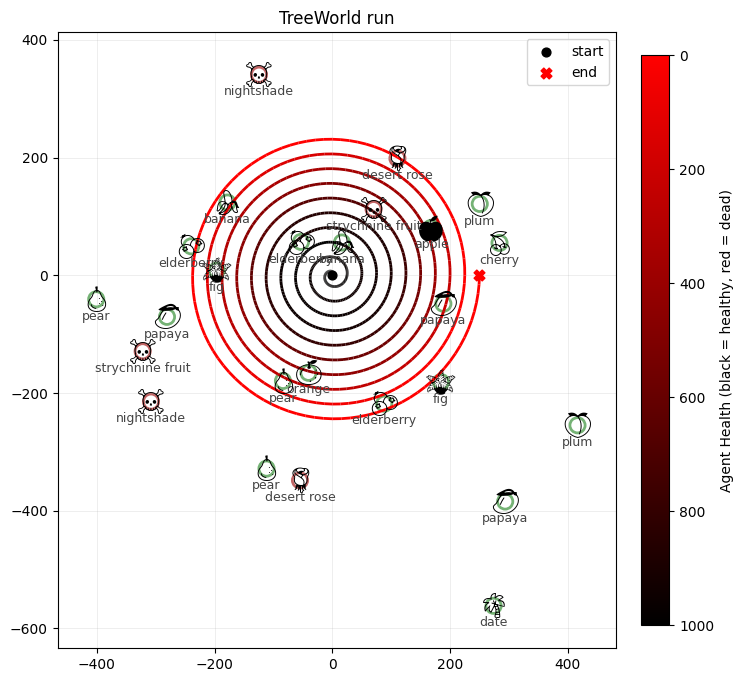

In [30]:
from tree_world.visualize import visualize_treeworld_run
visualize_treeworld_run(
    world.tree_locations.numpy().tolist(),
    [tree.name for tree in world.trees],
    [tree.is_poisonous for tree in world.trees],
    world.record_positions,
    world.record_healths,
    world.config.max_health,
    title="TreeWorld run",
    save_path="tree_world_run.png",
    show=False,
)

In [31]:
agent_location_history = torch.stack(world.agent.model.actual_location_history, dim=0)
geo_location_predictions = world.agent.model.last_location[0]
sense_location_predictions = world.agent.model.location_history[-1][0]

print(f"Agent location history: {agent_location_history.shape}  max: {agent_location_history.max()} min: {agent_location_history.min()}")
print(f"Geometric location predictions: {geo_location_predictions.shape}  max: {geo_location_predictions.max()} min: {geo_location_predictions.min()}")
print(f"Sense location predictions: {sense_location_predictions.shape}  max: {sense_location_predictions.max()} min: {sense_location_predictions.min()}")

Agent location history: torch.Size([1000, 2])  max: 249.25717163085938 min: -243.75
Geometric location predictions: torch.Size([1000, 120])  max: 1.1632814407348633 min: -1.1632578372955322
Sense location predictions: torch.Size([1000, 120])  max: 3.305638313293457 min: -3.143988847732544


Now that we have a model, let's try to see if we can decode the locations meaningfully. We'll try two different things:
1. Train an MLP to predict $\alpha_j$ and $\phi_{ij}$ for an explicit grid model, using known agent locations.
2. Train an MLP to predict the agent locations directly and vice versa, checking to see if there is a bidirectional interpretation

In [34]:
import sys

class MLP(torch.nn.Module):
    def __init__(self, input_dim: int, output_dim: int, hidden_dim: int=128):
        super().__init__()
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, output_dim),
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.mlp(x)


def fit_mlp(mlp: torch.nn.Module, input_tensor: torch.Tensor, output_tensor: torch.Tensor, steps: int=1000):
    optimizer = torch.optim.AdamW(mlp.parameters(), lr=1e-3)
    for i in range(steps):
        optimizer.zero_grad()
        output = mlp(input_tensor)
        loss = torch.nn.functional.mse_loss(output, output_tensor)
        loss.backward()
        optimizer.step()
        if i % 100 == 0:
            print(f"Step {i} loss: {loss.item()}", end="\r")
            sys.stdout.flush()
    
    print(f"Final loss: {loss.item()}")

def fit_indirect_model(agent_location_history: torch.Tensor, location_predictions: torch.Tensor):
    B, D = location_predictions.shape
    _, d = agent_location_history.shape
    # Fit an MLP to predict $\alpha_j$ and $\phi_{ij}$ for an explicit grid model, using known agent locations.
    loc_to_grid_mlp = MLP(2, D)
    print("Fitting location code --> explicit location with indirect model")
    fit_mlp(loc_to_grid_mlp, agent_location_history, location_predictions)

    grid_to_loc_mlp = MLP(D, 2)
    print("Fitting explicit location --> location code with indirect model")
    fit_mlp(grid_to_loc_mlp, location_predictions, agent_location_history)

    return loc_to_grid_mlp, grid_to_loc_mlp


print("Checking indirect fit with geometric location predictions")
loc_to_grid_mlp, grid_to_loc_mlp = fit_indirect_model(agent_location_history, geo_location_predictions)

print("Checking indirect fit with sense location predictions")
loc_to_grid_mlp, grid_to_loc_mlp = fit_indirect_model(agent_location_history, sense_location_predictions)


Checking indirect fit with geometric location predictions
Fitting location code --> explicit location with indirect model
Final loss: 0.38745582103729255453
Fitting explicit location --> location code with indirect model
Final loss: 1935.23266601562525
Checking indirect fit with sense location predictions
Fitting location code --> explicit location with indirect model
Final loss: 0.28923249244689943236
Fitting explicit location --> location code with indirect model
Final loss: 4101.92871093756875


In [33]:
class GridMLP2d(MLP):
    def __init__(self, location_dim: int, hidden_dim: int=128):
        super().__init__(2, location_dim, hidden_dim)
        self.ks = torch.tensor([
            [0, 1],
            [math.sqrt(3)/2, -0.5],
            [-math.sqrt(3)/2, -0.5],
        ])
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        y = self.mlp(x)
        alpha, phi = y.chunk(2, dim=-1)

        kx = torch.matmul(x, self.ks.T)
        eta_cos = torch.cos(alpha * kx + phi)
        eta_sin = torch.sin(alpha * kx + phi)

        return torch.stack([eta_cos, eta_sin], dim=-1).view_as(y)


def fit_grid_model(agent_location_history: torch.Tensor, location_predictions: torch.Tensor):
    grid_mlp = GridMLP2d(2)
    fit_mlp(grid_mlp, agent_location_history, location_predictions)

    return grid_mlp


print("Fitting grid model with geometric location predictions")
grid_mlp = fit_grid_model(agent_location_history, geo_location_predictions)

print("Fitting grid model with sense location predictions")
grid_mlp = fit_grid_model(agent_location_history, sense_location_predictions)




Fitting grid model with geometric location predictions


RuntimeError: shape '[1000, 2]' is invalid for input of size 6000